# MgCr2O4 analysis

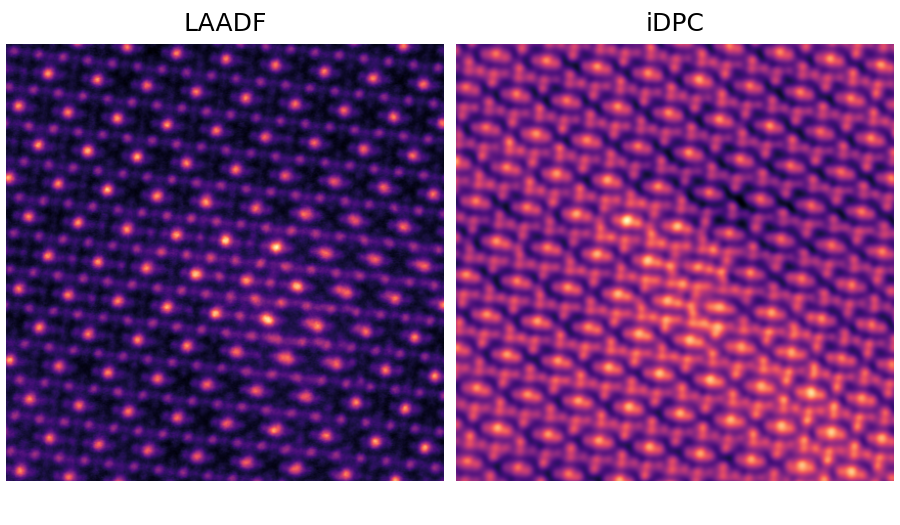

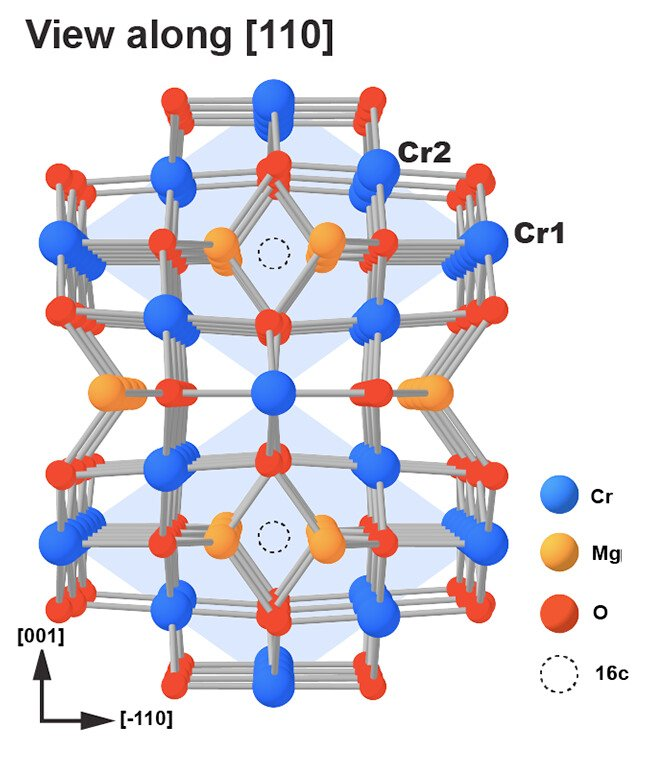

[1] Kim, J. et al. Elucidating Structural Transition Dynamics in the Magnesium Cathode MgCr2O4. Chem. Mater. 35, 8455–8463 (2023).

## Problems 
 - Trouble imaging Mg and O atoms w/ ADF
 - iDPC very sensitive to mistilt and thickness
 - Depth confuses atom identification (Cr or Mg?)

In [ ]:
%reload_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize

## Data loading

(we'll go a little faster)

In [ ]:
from util.io import load_foldslice
from util.filter import remove_linear_ramp

obj, obj_sampling = load_foldslice("data/MgCr2O4.mat")
phase = remove_linear_ramp(np.angle(obj))
phase -= np.nanquantile(phase, 0.1)

print(f"type(obj): {type(obj)}")
print(f"obj dtype: {obj.dtype} shape: {obj.shape}")

In [ ]:
contrast = np.std(phase, axis=(-1, -2))

fig, ax = plt.subplots(figsize=(6, 3))
ax.set_ylabel("Contrast")
ax.set_xlabel("Slice #")

ax.bar(np.arange(len(phase)), contrast, width=0.9)

plt.show()

In [ ]:
obj_crop = obj[5:15]

fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, constrained_layout=True)
fig.set_size_inches(8, 4)
axs[0].set_axis_off()
axs[1].set_axis_off()

mean_phase = np.mean(np.angle(obj_crop), axis=0)
mean_int = np.mean(np.abs(obj_crop)**2, axis=0)

fig.suptitle("Mean image")
fig.colorbar(axs[0].imshow(mean_phase), label="Mean phase [rad]", shrink=0.7)
fig.colorbar(axs[1].imshow(mean_int, vmax=1.0), label="Mean intensity", shrink=0.7)
plt.show()

In [ ]:
from util.peaks import find_peaks

template_sigma = 1.5  # std. deviation of Gaussian template (px)
threshold_corr = 0.7  # threshold normalized cross correlation to consider it a peak

# check the definition of this function to see the details
(cross_corr, peaks) = find_peaks(mean_phase, template_sigma, threshold_corr, min_distance=3)

fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)
axs[0].set_title("Mean phase")
axs[0].imshow(mean_phase)

axs[1].set_title("Cross correlation")
axs[1].imshow(cross_corr, cmap='bwr', vmin=-1.0, vmax=1.0)

axs[0].scatter(peaks[..., 1], peaks[..., 0], s=2, c='red')
axs[1].scatter(peaks[..., 1], peaks[..., 0], s=2, c='red')

plt.show()


In [ ]:
from util.peaks import integrate_peaks

# integrate in 0.5 angstrom radius
peak_ints = integrate_peaks(mean_phase, peaks, 0.5 / obj_sampling[0])

fig, axs = plt.subplots(ncols=2, constrained_layout=True, gridspec_kw={'width_ratios': [4, 1]})
axs[0].set_axis_off()
axs[1].set_ylabel("Mean Phase @ peak")

vmin, vmax = float(np.min(peak_ints)), float(np.max(peak_ints))

cmap = plt.get_cmap('magma')
norm = Normalize(vmin, vmax)

axs[0].imshow(mean_phase, cmap='gray')
axs[0].scatter(peaks[:, 1], peaks[:, 0], s=2, c=peak_ints, cmap=cmap, norm=norm)

hist, bins = np.histogram(peak_ints, 50, range=(vmin, vmax))
bin_heights = bins[1:] - bins[:-1]  # type: ignore
axs[1].barh(bins[:-1], hist, height=bin_heights, align='edge', color=cmap(norm(bins[:-1])))

plt.show()

Again, we nicely identify each atom type.

We'll take a different approach to identifying the sublattices. Previously, we've stored the peak positions in an unsorted, flat list--making measurements on the lattice difficult. In this notebook, we'll index the atom columns into a matrix, and use that matrix to find the sublattices. This allows us to identify sites that are nominally empty--like the 16c site.

First, we'll filter out the corners of our lattice, the bright Cr columns

In [ ]:
# filter out Cr sites

threshold = 17.0

cr_peaks = peaks[peak_ints > threshold]
cr_peak_ints = peak_ints[peak_ints > threshold]
print(f"cr_peaks: {len(cr_peaks)}/{len(peaks)}")

fig, ax = plt.subplots()
ax.set_axis_off()

ax.imshow(mean_phase, cmap='gray')
ax.scatter(cr_peaks[:, 1], cr_peaks[:, 0], s=2, c=cr_peak_ints, cmap=cmap, norm=norm)

plt.show()

Now, we identify high symmetry directions in the crystal.

In [ ]:
from util.index import find_lattice_directions
from util.plot import plot_found_lattice_directions

found_dirs = find_lattice_directions(mean_phase, n_peaks=5)

plot_found_lattice_directions(found_dirs);

Direction #1 and #2 look like what we want. We index using those as our basis vectors:

In [ ]:
from util.index import graph_index

x_dir = 1
y_dir = 2

grid_indices, grid_peaks = graph_index(cr_peaks, found_dirs, x_dir=x_dir, y_dir=y_dir)

fig, axs = plt.subplots(ncols=4, constrained_layout=True)
fig.set_size_inches(8, 3)
[ax.set_axis_off() for ax in axs.flat]

axs[0].imshow(grid_peaks[..., 0])
axs[0].set_title("Y peak position")
axs[1].imshow(grid_peaks[..., 1])
axs[1].set_title("X peak position")

rr, cc = np.indices(grid_indices.shape)

axs[2].imshow(mean_phase, cmap='gray')
axs[2].scatter(grid_peaks[..., 1].ravel(), grid_peaks[..., 0].ravel(), s=5, c=rr.ravel())
axs[2].set_title("Peak Row #")

axs[3].imshow(mean_phase, cmap='gray')
axs[3].scatter(grid_peaks[..., 1].ravel(), grid_peaks[..., 0].ravel(), s=5, c=cc.ravel())
axs[3].set_title("Peak Col #")

plt.show()

On the left is our matrix of unit cells. We know the origin of each unit cell. Unit cells outside the image are 'masked'.
On the right is the inverse, a map of which row and column # each Cr column belongs to.

Using this map, we can construct any sublattice we want.

In [ ]:
from util.index import construct_grid_points

# these are fractional coordinates on the unit cell
cr1_peaks = construct_grid_points(grid_peaks, [0., 0.])
cr2_peaks = construct_grid_points(grid_peaks, [[0., 0.5], [0.5, 0.]])
o1_peaks = construct_grid_points(grid_peaks, [[1/4, 3/4], [3/4, 1/4]])
o2_peaks = construct_grid_points(grid_peaks, [[1/4, 1/4], [3/4, 3/4]])
mg_peaks = construct_grid_points(grid_peaks, [[1/2 + 1/8, 1/2 - 1/8], [1/2 - 1/8, 1/2 + 1/8]])
inter_peaks = construct_grid_points(grid_peaks, [[1/2, 1/2]])

fig, ax = plt.subplots(constrained_layout=True)
ax.set_axis_off()

ax.imshow(mean_phase)
s = 10
ax.scatter(cr1_peaks[:, 1], cr1_peaks[:, 0], s=s, c='blue', label="Cr1")
ax.scatter(cr2_peaks[:, 1], cr2_peaks[:, 0], s=s, c='cyan', label="Cr2")
ax.scatter(o1_peaks[:, 1], o1_peaks[:, 0], s=s, c='red', label="O1")
ax.scatter(o2_peaks[:, 1], o2_peaks[:, 0], s=s, c='lightcoral', label="O2")
ax.scatter(mg_peaks[:, 1], mg_peaks[:, 0], s=s, c='orange', label="Mg")
ax.scatter(inter_peaks[:, 1], inter_peaks[:, 0], s=s, c='white', label="16c")

ax.legend(loc='lower right')

plt.show()

With these sublattices, we can perform peak integration:

In [ ]:
from util.plot import plot_voronoi

integration_radius = 0.5

mg_peak_ints = integrate_peaks(mean_phase, mg_peaks, integration_radius / obj_sampling[0])
inter_peak_ints = integrate_peaks(mean_phase, inter_peaks, integration_radius / obj_sampling[0])

fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

axs[0].set_axis_off()
axs[1].set_axis_off()
axs[0].imshow(mean_phase, cmap='gray')
axs[1].imshow(mean_phase, cmap='gray')

axs[0].set_title("Mg peak intensities")
plot_voronoi(axs[0], mg_peaks[..., 1], mg_peaks[..., 0], mg_peak_ints, mean_phase.shape, cmap='magma', max_r=integration_radius / obj_sampling[0])
axs[1].set_title("16c intensities")
plot_voronoi(axs[1], inter_peaks[..., 1], inter_peaks[..., 0], inter_peak_ints, mean_phase.shape, cmap='magma', max_r=integration_radius / obj_sampling[0])

plt.show()

And look as a function of depth:

In [ ]:
from matplotlib.animation import FuncAnimation
from ipywidgets import HTML

plt.close('all')

integration_radius = 0.5

inter_peak_ints_depth = np.stack([
    integrate_peaks(slice_phase, inter_peaks, integration_radius / obj_sampling[0])
    for slice_phase in phase
], axis=0)

fig, axs = plt.subplots(ncols=2, constrained_layout=True, sharex=True, sharey=True)
fig.set_size_inches(8, 4)

axs[0].set_axis_off() 
axs[1].set_axis_off()
axs[1].set_title("16c intensities")

layer = 0

img_vmin, img_vmax = float(np.nanmin(phase[5:15])), float(np.nanmax(phase[5:15]))
img = axs[0].imshow(phase[layer], cmap='gray', vmin=img_vmin, vmax=img_vmax)

vmin, vmax = float(np.nanmin(inter_peak_ints_depth[5:15])), float(np.nanmax(inter_peak_ints_depth[5:15]))
quadmesh = plot_voronoi(axs[1], inter_peaks[..., 1], inter_peaks[..., 0], inter_peak_ints_depth[layer], mean_phase.shape,
                        cmap='magma', vmin=vmin, vmax=vmax, max_r=integration_radius / obj_sampling[0])

text = axs[0].text(0.03, 0.97, f"layer: {layer:2}", ha='left', va='top', transform=axs[0].transAxes, color='red')

def animate(layer: int):
    global quadmesh
    if quadmesh is not None:
        quadmesh.remove()
    quadmesh = plot_voronoi(axs[1], inter_peaks[..., 1], inter_peaks[..., 0], inter_peak_ints_depth[layer], mean_phase.shape,
                            cmap='magma', vmin=vmin, vmax=vmax)

    img.set_data(phase[layer])
    text.set_text(f"layer: {layer:2}")
    return ()

fig.draw_without_rendering()
anim = FuncAnimation(fig, animate, frames=len(phase), interval=1000)

anim.save("interstitial_intensities.mp4", dpi=300, fps=3)
#display(HTML(anim.to_jshtml(fps=3)))

plt.close(fig)

In [ ]:
plt.close('all')

## Take-home Exercises

1. Plot the Mg site intensity as a function of depth

2. Perform 2D Gaussian peak fitting on the Mg sites